In [1]:
import mlflow
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from collections import defaultdict

import sys
sys.path.insert(0, "../../run")
from const import REPO_PATH
from experiment_config import TRAINGING_CONFIG

sys.path.insert(1, f"{REPO_PATH}")
from src.model.experiment_utils import *
from src.model.model_utils import *
from src.model.models import MLPWithDropout, MLPWithDropoutBN

In [2]:
features_path = f"{TRAINGING_CONFIG['features_path']}/all_combined_features_2017-24.csv"
output_dir = f"{REPO_PATH}/models/ml_models"

In [3]:
seasons=sorted(TRAINGING_CONFIG['seasons'])
target_dfs=[pd.read_csv(f"{TRAINGING_CONFIG['processed_data_path']}/{season}/all_target_df.csv") for season in seasons[1:]]
for df in target_dfs:
    df['date']= pd.to_datetime(df['date'])
target_df = pd.concat(target_dfs, ignore_index=True)
target_columns=target_df.drop(columns=TRAINGING_CONFIG['key_columns']).columns.tolist()

In [4]:
feature_df = pd.read_csv(features_path)
feature_df['date']= pd.to_datetime(feature_df['date'])
feature_df, target_df=align_on_keys(feature_df, target_df, TRAINGING_CONFIG['key_columns'])

In [5]:
param_grid = {
    'model_params.hidden_layers': [(512, 128, 128, 128, 64), (256, 128, 128, 64)],
    'model_params.activation': ['relu'],
    'model_params.dropout_rate': [0.1],
    'learning_rate': [0.00001, 0.0001],
    'batch_size': [64, 128],
    'epochs': [2000]
}


In [6]:
feature_df.fillna(-1, inplace=True)

In [7]:
numeric_cols = feature_df.select_dtypes(include=[np.number]).columns

scaler = StandardScaler()
feature_df[numeric_cols] = scaler.fit_transform(feature_df[numeric_cols])

In [8]:
feature_df.shape

(2660, 2729)

Training MLPwithDropoutBN on home_goals with param grid: {'model_params.hidden_layers': [(512, 128, 128, 128, 64), (256, 128, 128, 64)], 'model_params.activation': ['relu'], 'model_params.dropout_rate': [0.1], 'learning_rate': [1e-05, 0.0001], 'batch_size': [64, 128], 'epochs': [2000]}
Using range-based class conversion with range: (0, 5)
Training fold 1/5 with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


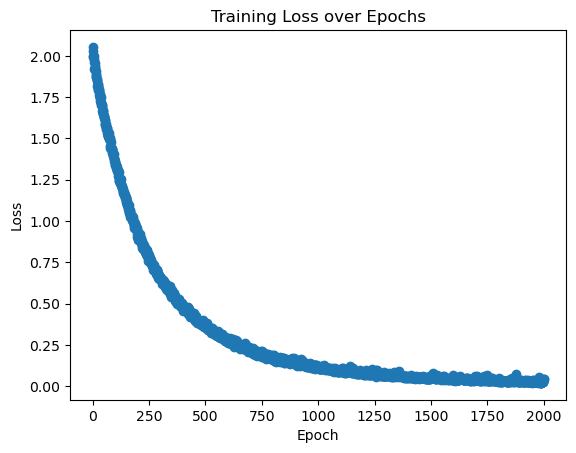

Final training loss: 0.04263487824222498
Training fold 2/5 with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


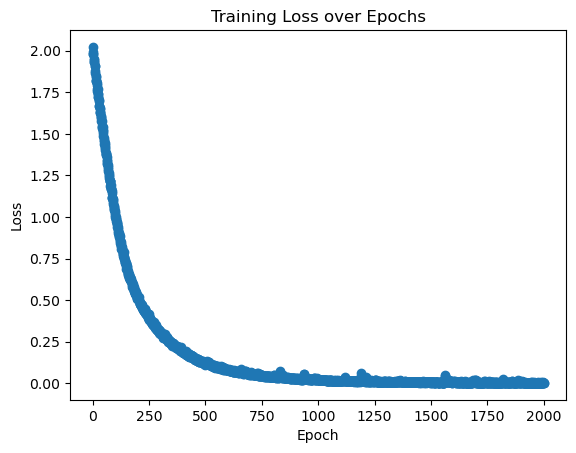

Final training loss: 0.002329572840339334
Training fold 3/5 with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


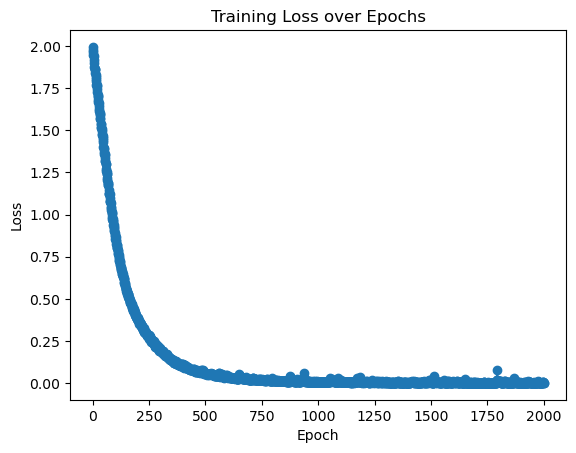

Final training loss: 0.002161080965760795
Training fold 4/5 with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


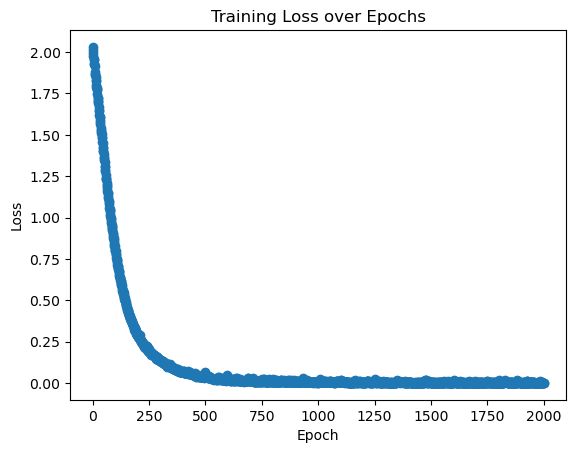

Final training loss: 0.0022508321387721296
Training fold 5/5 with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


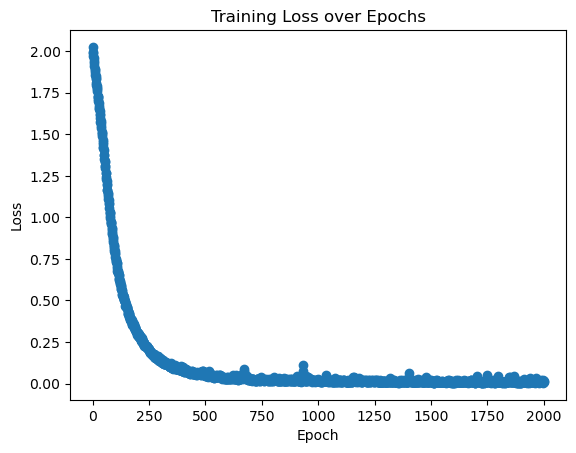

Final training loss: 0.01704030686751344
[TorchWrapper] Using device: mps


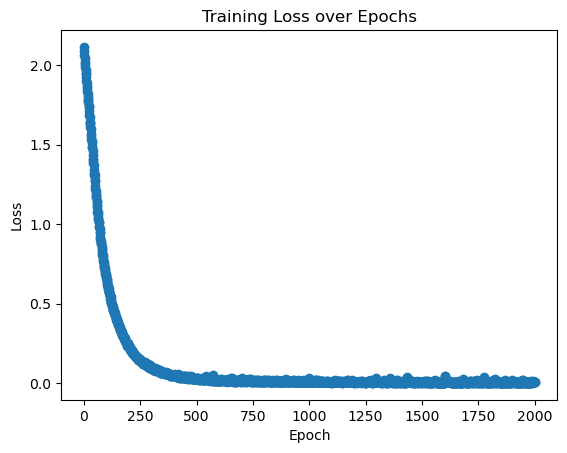

Final training loss: 0.005695315377449083
{'home_goals_train_accuracy': 1.0, 'home_goals_train_precision': 1.0, 'home_goals_valid_accuracy': 0.2696741854636592, 'home_goals_valid_precision': 0.14781432514771692, 'home_goals_test_accuracy': 0.2706766917293233, 'home_goals_test_precision': 0.1554844351533717, 'home_goals_train_lte_0_accuracy': 1.0, 'home_goals_train_lte_0_accuracy_std': 0.0, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_gt_0_accuracy': 1.0, 'home_goals_train_gt_0_accuracy_std': 0.0, 'home_goals_train_gt_0_precision': 1.0, 'home_goals_train_gt_0_precision_std': 0.0, 'home_goals_train_gt_1_accuracy': 1.0, 'home_goals_train_gt_1_accuracy_std': 0.0, 'home_goals_train_gt_1_precision': 1.0, 'home_goals_train_gt_1_precision_std': 0.0, 'home_goals_train_gt_2_accuracy': 1.0, 'home_goals_train_gt_2_accuracy_std': 0.0, 'home_goals_train_gt_2_precision': 1.0, 'home_goals_train_gt_2_precision_std': 0.0, 'home_goals_train_gt_3_

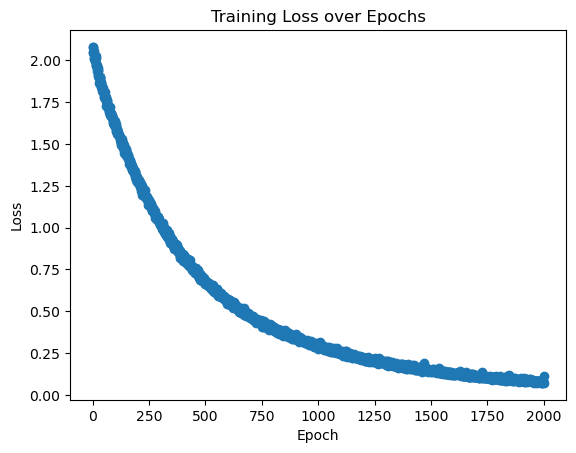

Final training loss: 0.07313059681190882
Training fold 2/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


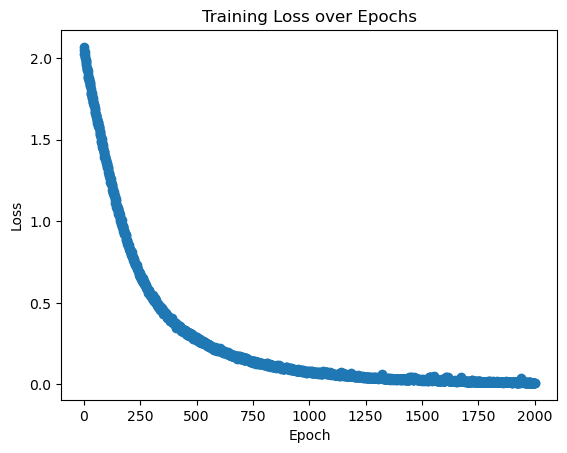

Final training loss: 0.009808957649110104
Training fold 3/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


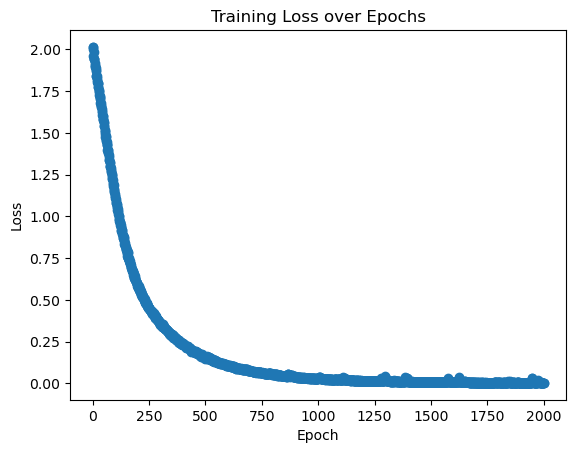

Final training loss: 0.002604348325919836
Training fold 4/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


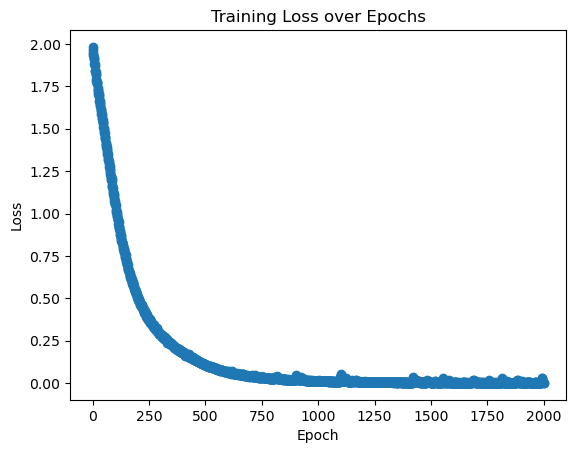

Final training loss: 0.0023226357575151183
Training fold 5/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


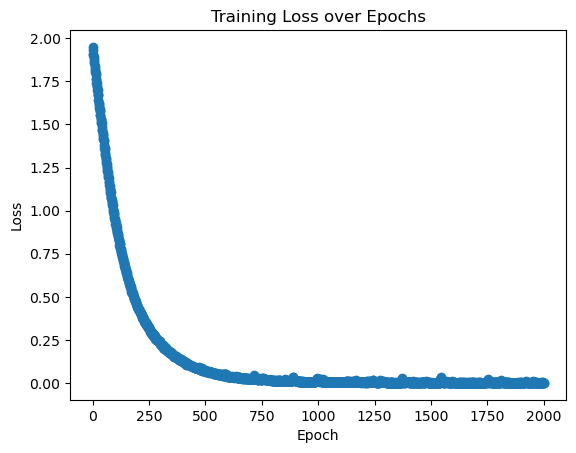

Final training loss: 0.0017807295226449974
[TorchWrapper] Using device: mps


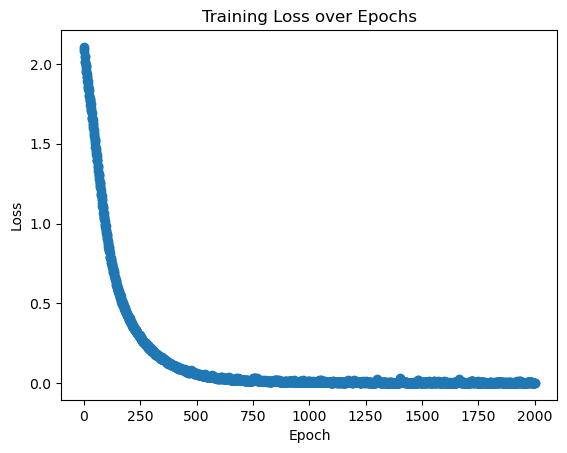

Final training loss: 0.0010648847724106427
{'home_goals_train_accuracy': 0.9984962406015038, 'home_goals_train_precision': 0.9988397090437907, 'home_goals_valid_accuracy': 0.26917293233082706, 'home_goals_valid_precision': 0.15324994472539277, 'home_goals_test_accuracy': 0.2706766917293233, 'home_goals_test_precision': 0.14213640275387263, 'home_goals_train_lte_0_accuracy': 0.9989974937343359, 'home_goals_train_lte_0_accuracy_std': 0.0020050125313283208, 'home_goals_train_lte_0_precision': 0.9959595959595958, 'home_goals_train_lte_0_precision_std': 0.00808080808080809, 'home_goals_train_gt_0_accuracy': 0.9989974937343359, 'home_goals_train_gt_0_accuracy_std': 0.0020050125313283208, 'home_goals_train_gt_0_precision': 1.0, 'home_goals_train_gt_0_precision_std': 0.0, 'home_goals_train_gt_1_accuracy': 0.9989974937343359, 'home_goals_train_gt_1_accuracy_std': 0.0020050125313283208, 'home_goals_train_gt_1_precision': 1.0, 'home_goals_train_gt_1_precision_std': 0.0, 'home_goals_train_gt_2_acc

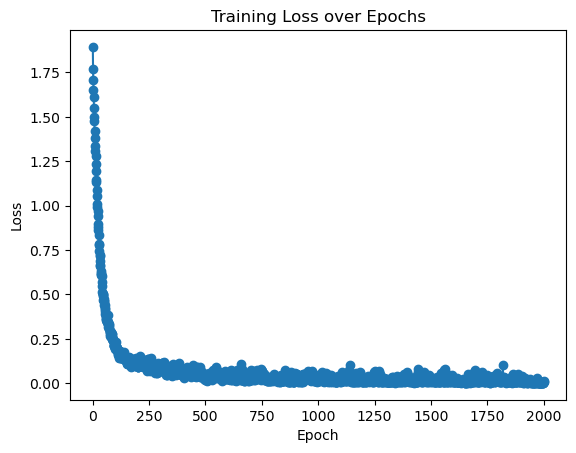

Final training loss: 0.01069845271327143
Training fold 2/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


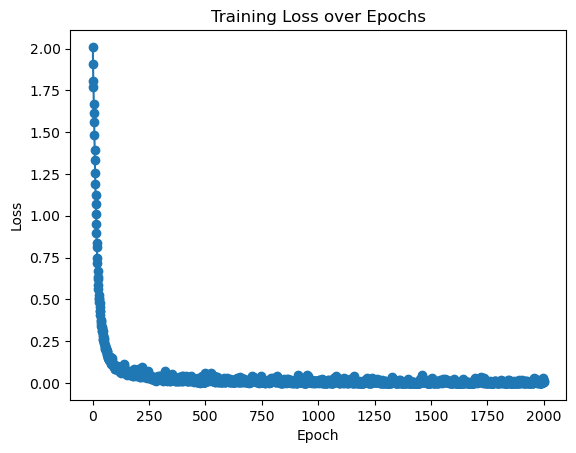

Final training loss: 0.00805195226313028
Training fold 3/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


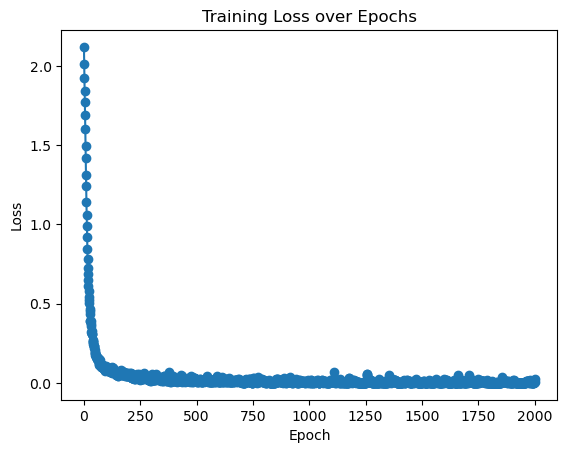

Final training loss: 0.023585887172989976
Training fold 4/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


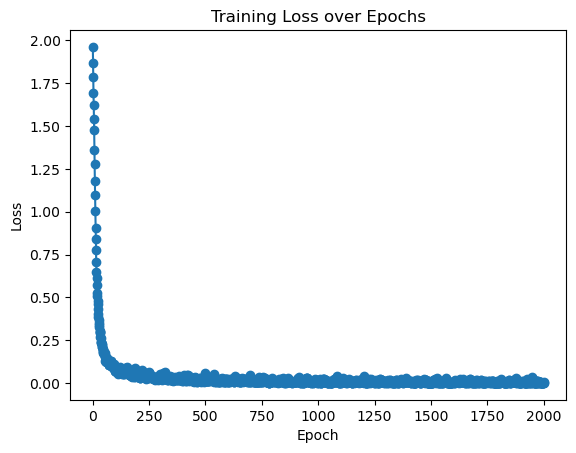

Final training loss: 0.004825146413667309
Training fold 5/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


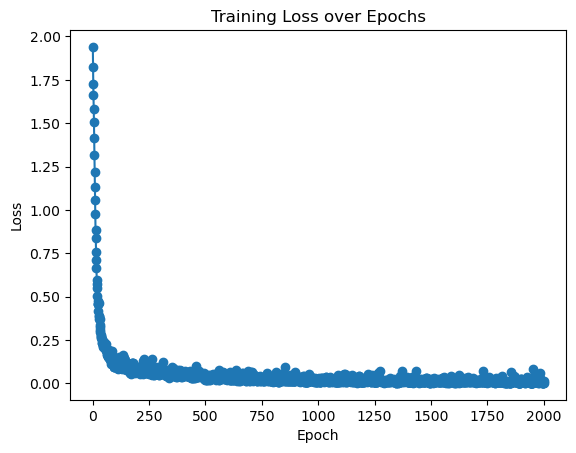

Final training loss: 0.013316477458914719
[TorchWrapper] Using device: mps


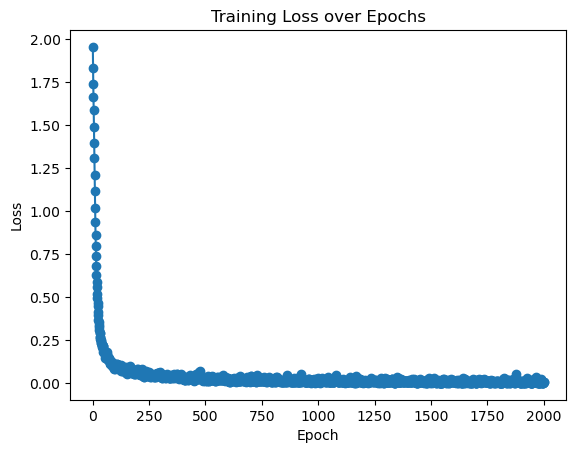

Final training loss: 0.007539392033289984
{'home_goals_train_accuracy': 0.9991228070175439, 'home_goals_train_precision': 0.9991625004157013, 'home_goals_valid_accuracy': 0.27669172932330827, 'home_goals_valid_precision': 0.16406745138914042, 'home_goals_test_accuracy': 0.29699248120300753, 'home_goals_test_precision': 0.1500502185986057, 'home_goals_train_lte_0_accuracy': 1.0, 'home_goals_train_lte_0_accuracy_std': 0.0, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_gt_0_accuracy': 1.0, 'home_goals_train_gt_0_accuracy_std': 0.0, 'home_goals_train_gt_0_precision': 1.0, 'home_goals_train_gt_0_precision_std': 0.0, 'home_goals_train_gt_1_accuracy': 0.999749373433584, 'home_goals_train_gt_1_accuracy_std': 0.000501253132832069, 'home_goals_train_gt_1_precision': 1.0, 'home_goals_train_gt_1_precision_std': 0.0, 'home_goals_train_gt_2_accuracy': 0.9993734335839598, 'home_goals_train_gt_2_accuracy_std': 0.0012531328320802171, 'home_goals

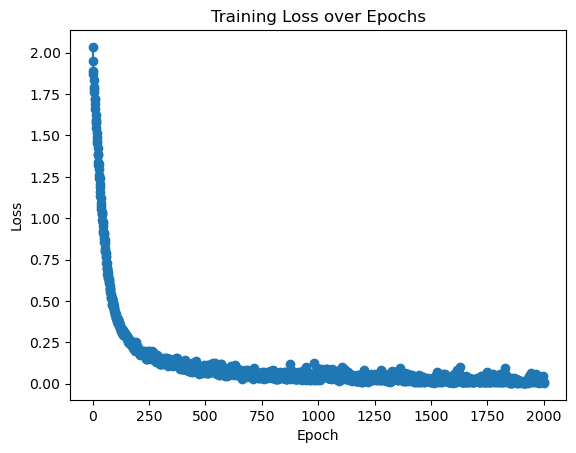

Final training loss: 0.007736262970400932
Training fold 2/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


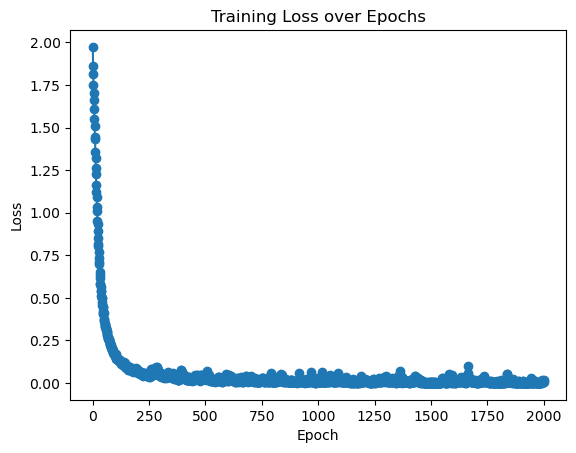

Final training loss: 0.0054977040896589
Training fold 3/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


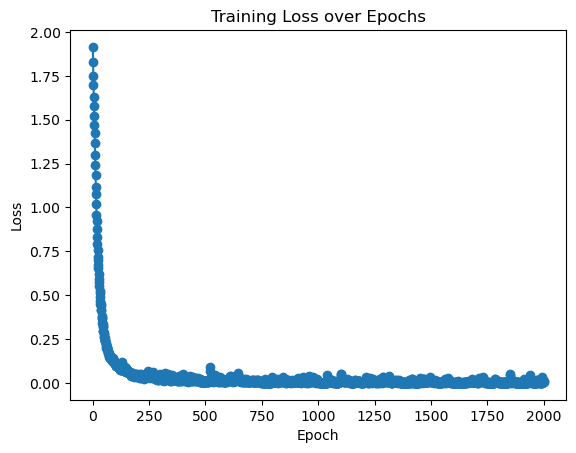

Final training loss: 0.010142515123251487
Training fold 4/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


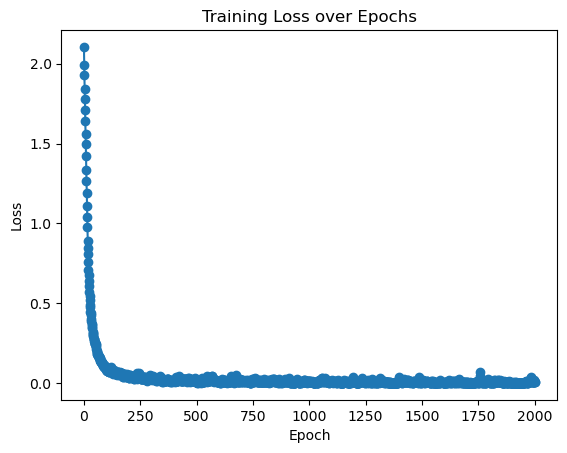

Final training loss: 0.005147027601032777
Training fold 5/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


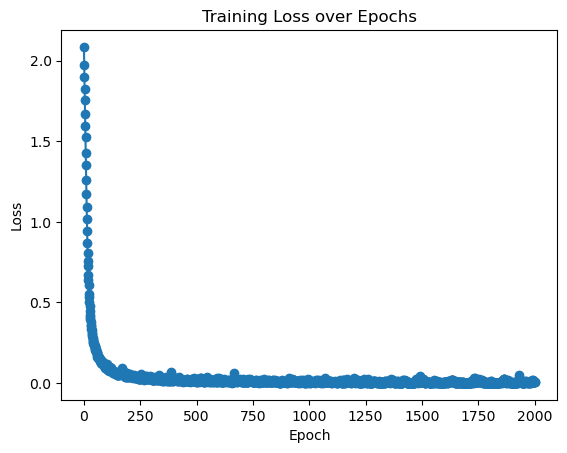

Final training loss: 0.003928020618445144
[TorchWrapper] Using device: mps


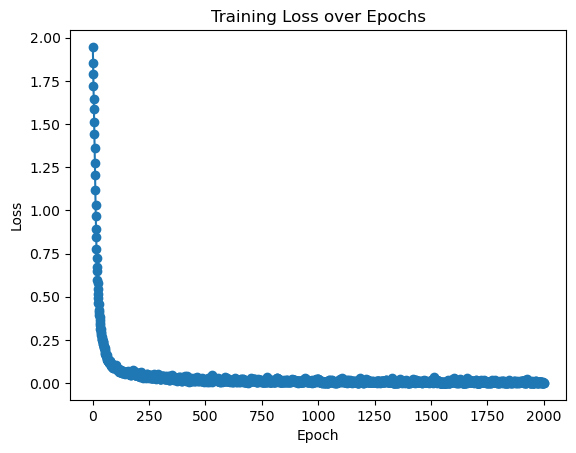

Final training loss: 0.002866000863128251
{'home_goals_train_accuracy': 1.0, 'home_goals_train_precision': 1.0, 'home_goals_valid_accuracy': 0.2822055137844611, 'home_goals_valid_precision': 0.1724022402441451, 'home_goals_test_accuracy': 0.2781954887218045, 'home_goals_test_precision': 0.14219642976405147, 'home_goals_train_lte_0_accuracy': 1.0, 'home_goals_train_lte_0_accuracy_std': 0.0, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_gt_0_accuracy': 1.0, 'home_goals_train_gt_0_accuracy_std': 0.0, 'home_goals_train_gt_0_precision': 1.0, 'home_goals_train_gt_0_precision_std': 0.0, 'home_goals_train_gt_1_accuracy': 1.0, 'home_goals_train_gt_1_accuracy_std': 0.0, 'home_goals_train_gt_1_precision': 1.0, 'home_goals_train_gt_1_precision_std': 0.0, 'home_goals_train_gt_2_accuracy': 1.0, 'home_goals_train_gt_2_accuracy_std': 0.0, 'home_goals_train_gt_2_precision': 1.0, 'home_goals_train_gt_2_precision_std': 0.0, 'home_goals_train_gt_3_

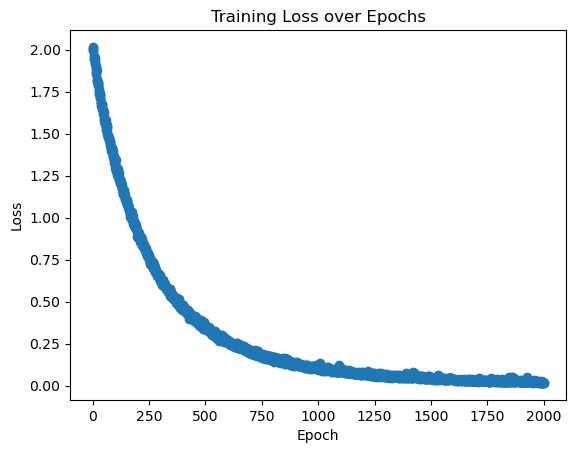

Final training loss: 0.017979657646259268
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


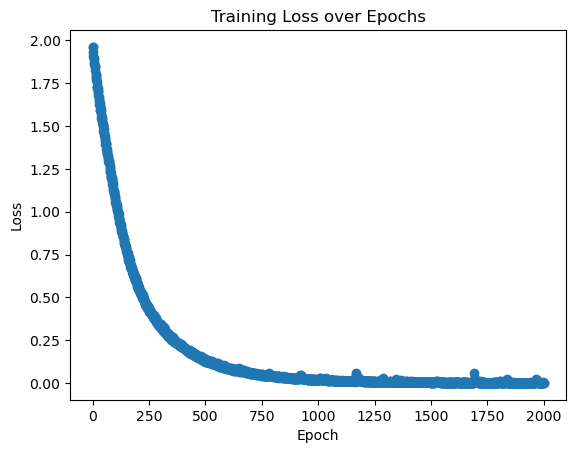

Final training loss: 0.00209096400096387
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


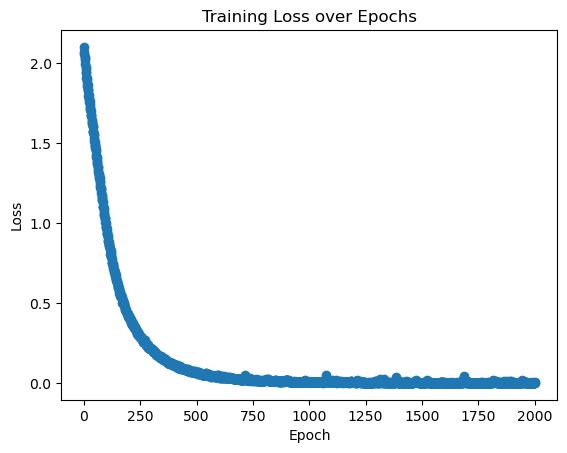

Final training loss: 0.002595925320650987
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


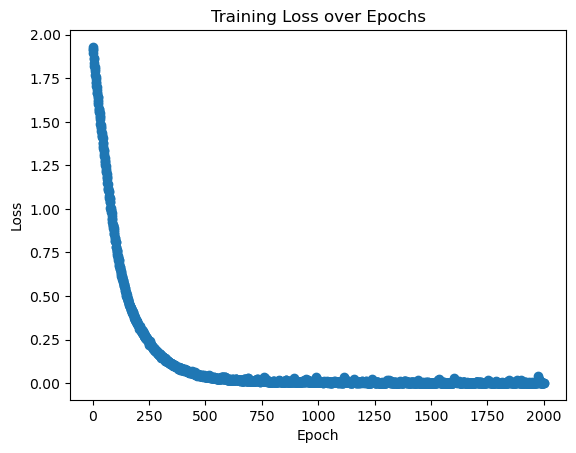

Final training loss: 0.0015979877134486287
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


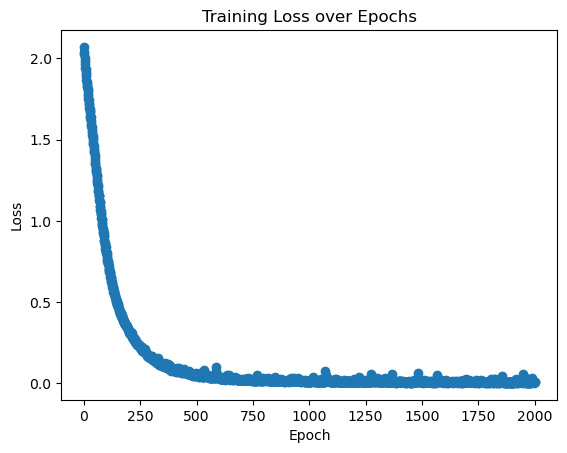

Final training loss: 0.008483185579902247
[TorchWrapper] Using device: mps


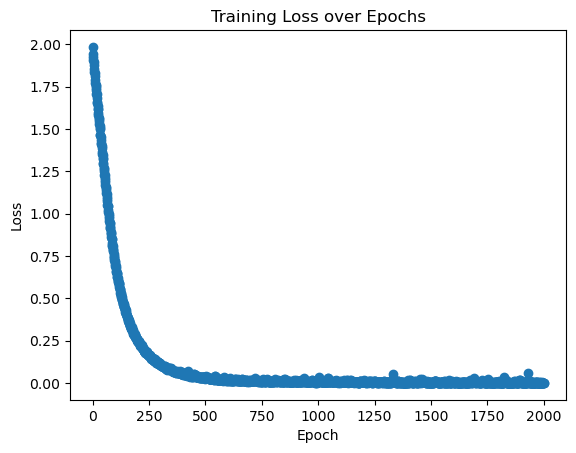

Final training loss: 0.00242726197989491
{'home_goals_train_accuracy': 1.0, 'home_goals_train_precision': 1.0, 'home_goals_valid_accuracy': 0.27167919799498746, 'home_goals_valid_precision': 0.18910661465546194, 'home_goals_test_accuracy': 0.2744360902255639, 'home_goals_test_precision': 0.16450346878911742, 'home_goals_train_lte_0_accuracy': 1.0, 'home_goals_train_lte_0_accuracy_std': 0.0, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_gt_0_accuracy': 1.0, 'home_goals_train_gt_0_accuracy_std': 0.0, 'home_goals_train_gt_0_precision': 1.0, 'home_goals_train_gt_0_precision_std': 0.0, 'home_goals_train_gt_1_accuracy': 1.0, 'home_goals_train_gt_1_accuracy_std': 0.0, 'home_goals_train_gt_1_precision': 1.0, 'home_goals_train_gt_1_precision_std': 0.0, 'home_goals_train_gt_2_accuracy': 1.0, 'home_goals_train_gt_2_accuracy_std': 0.0, 'home_goals_train_gt_2_precision': 1.0, 'home_goals_train_gt_2_precision_std': 0.0, 'home_goals_train_gt_3

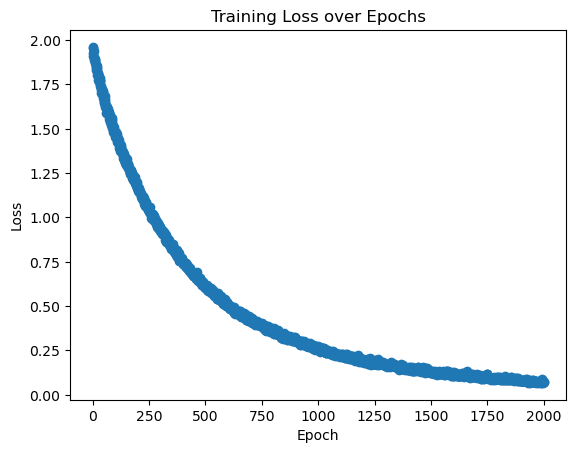

Final training loss: 0.07157881330129198
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


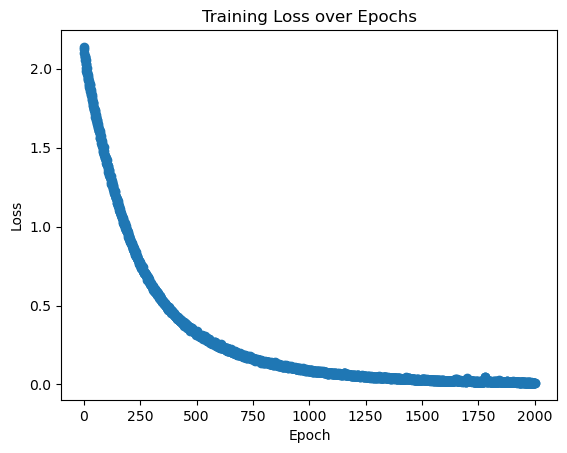

Final training loss: 0.01101553420253789
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


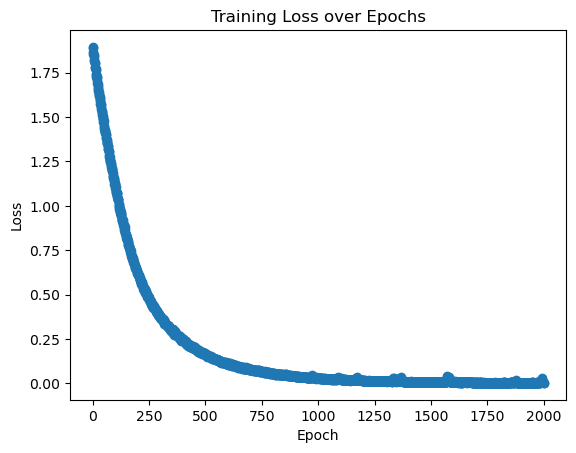

Final training loss: 0.0030858312031672762
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


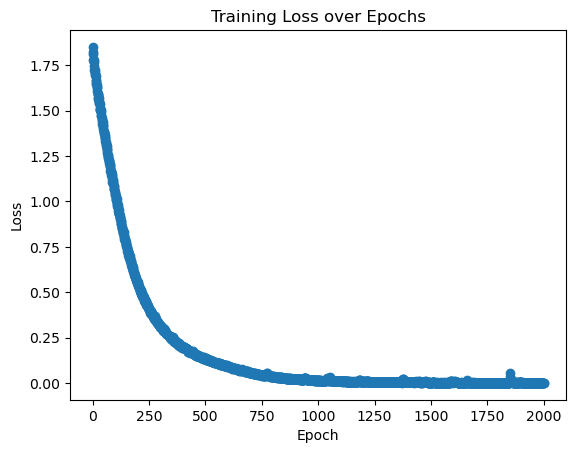

Final training loss: 0.001769857903601681
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


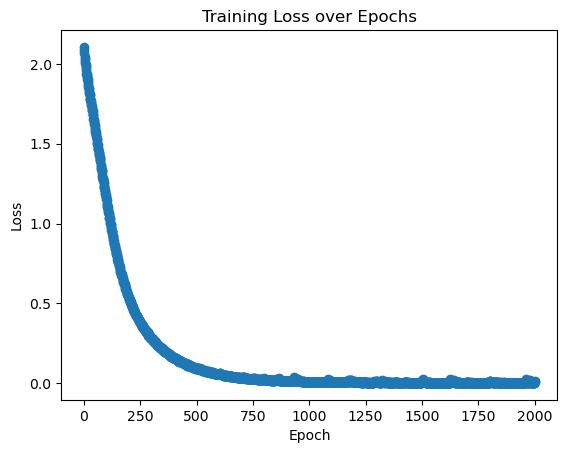

Final training loss: 0.005404006043871524
[TorchWrapper] Using device: mps


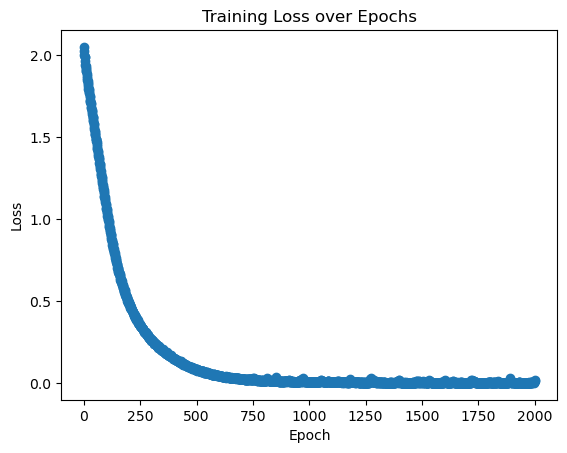

Final training loss: 0.010182688443757339
{'home_goals_train_accuracy': 1.0, 'home_goals_train_precision': 1.0, 'home_goals_valid_accuracy': 0.2646616541353383, 'home_goals_valid_precision': 0.1742219595885183, 'home_goals_test_accuracy': 0.2932330827067669, 'home_goals_test_precision': 0.15723254819169047, 'home_goals_train_lte_0_accuracy': 1.0, 'home_goals_train_lte_0_accuracy_std': 0.0, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_gt_0_accuracy': 1.0, 'home_goals_train_gt_0_accuracy_std': 0.0, 'home_goals_train_gt_0_precision': 1.0, 'home_goals_train_gt_0_precision_std': 0.0, 'home_goals_train_gt_1_accuracy': 1.0, 'home_goals_train_gt_1_accuracy_std': 0.0, 'home_goals_train_gt_1_precision': 1.0, 'home_goals_train_gt_1_precision_std': 0.0, 'home_goals_train_gt_2_accuracy': 1.0, 'home_goals_train_gt_2_accuracy_std': 0.0, 'home_goals_train_gt_2_precision': 1.0, 'home_goals_train_gt_2_precision_std': 0.0, 'home_goals_train_gt_3_

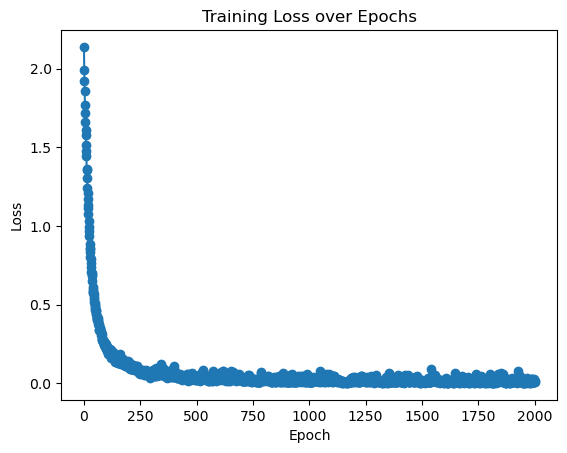

Final training loss: 0.0062079501518032005
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


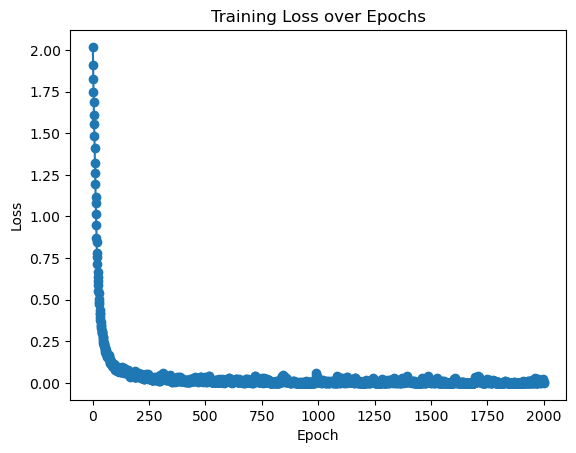

Final training loss: 0.003766665765011968
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


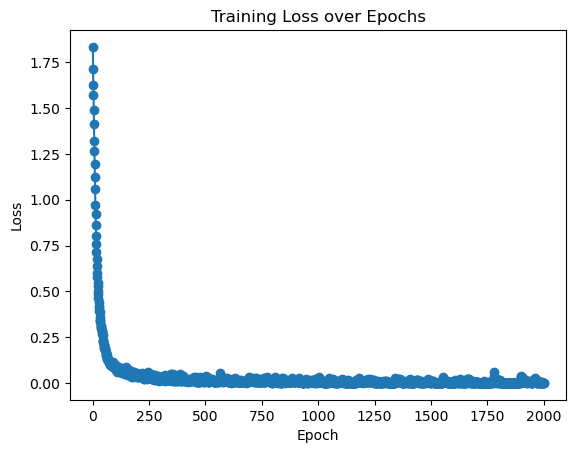

Final training loss: 0.0016932792809221749
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


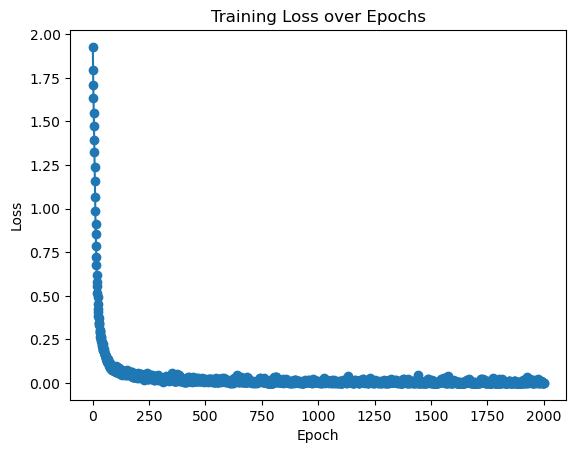

Final training loss: 0.0025062183792618825
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


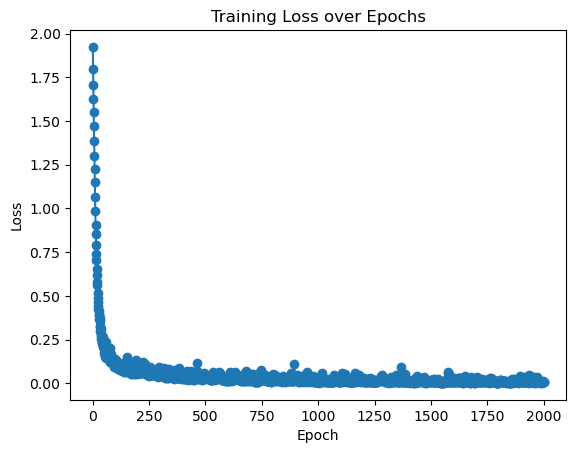

Final training loss: 0.006665861235002527
[TorchWrapper] Using device: mps


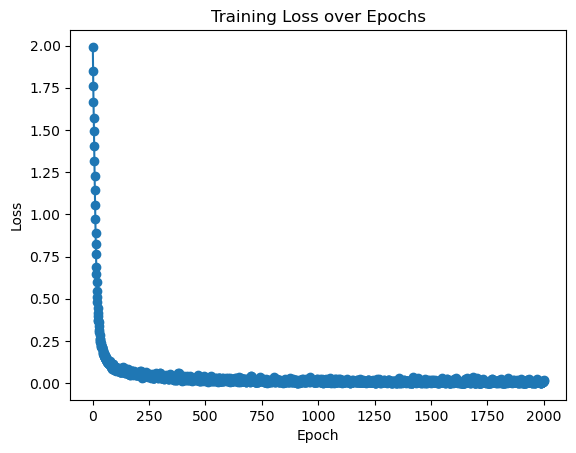

Final training loss: 0.010504406748873275
{'home_goals_train_accuracy': 1.0, 'home_goals_train_precision': 1.0, 'home_goals_valid_accuracy': 0.2616541353383458, 'home_goals_valid_precision': 0.16689745881005286, 'home_goals_test_accuracy': 0.3157894736842105, 'home_goals_test_precision': 0.17796705650110148, 'home_goals_train_lte_0_accuracy': 1.0, 'home_goals_train_lte_0_accuracy_std': 0.0, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_gt_0_accuracy': 1.0, 'home_goals_train_gt_0_accuracy_std': 0.0, 'home_goals_train_gt_0_precision': 1.0, 'home_goals_train_gt_0_precision_std': 0.0, 'home_goals_train_gt_1_accuracy': 1.0, 'home_goals_train_gt_1_accuracy_std': 0.0, 'home_goals_train_gt_1_precision': 1.0, 'home_goals_train_gt_1_precision_std': 0.0, 'home_goals_train_gt_2_accuracy': 1.0, 'home_goals_train_gt_2_accuracy_std': 0.0, 'home_goals_train_gt_2_precision': 1.0, 'home_goals_train_gt_2_precision_std': 0.0, 'home_goals_train_gt_3

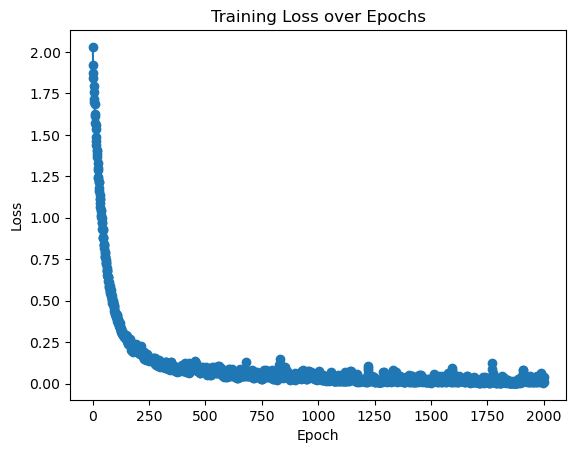

Final training loss: 0.040238705643436366
Training fold 2/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


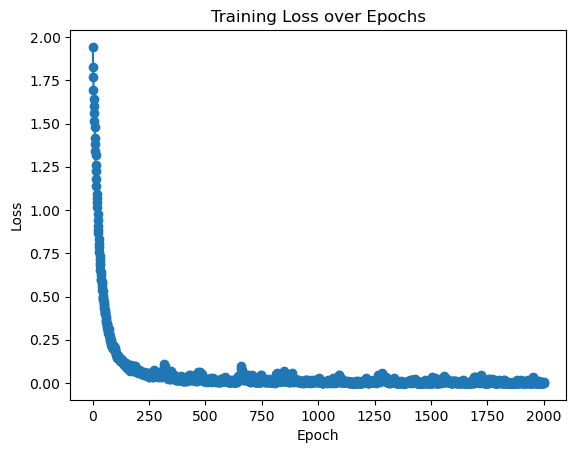

Final training loss: 0.0012588071214375937
Training fold 3/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


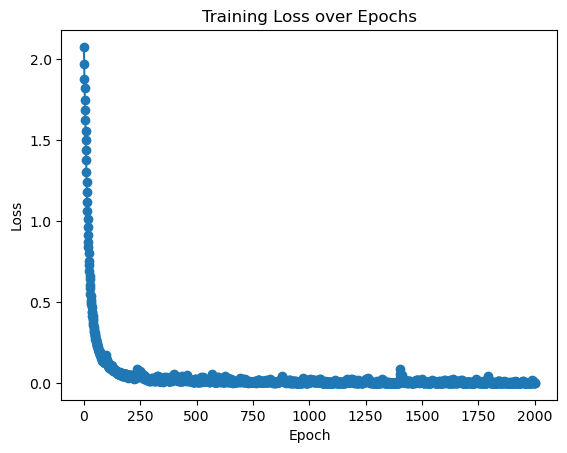

Final training loss: 0.0014420756669489413
Training fold 4/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


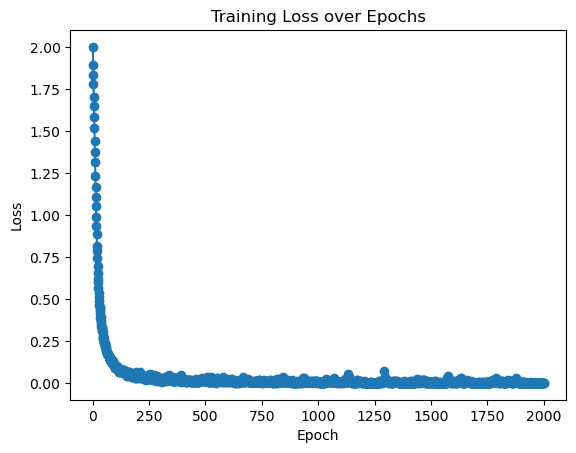

Final training loss: 0.0005465396533689267
Training fold 5/precision with params: {'model_params.hidden_layers': (256, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


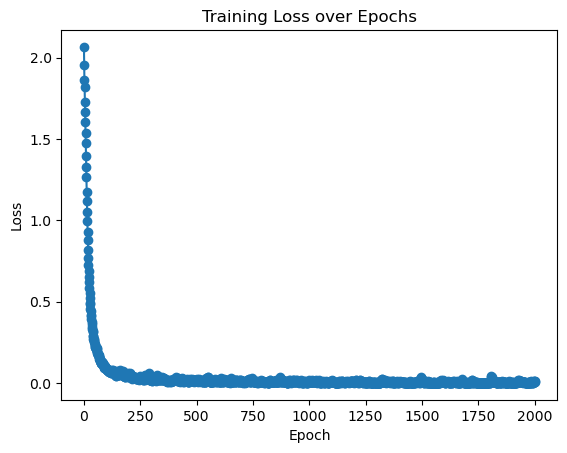

Final training loss: 0.005344255052198817
[TorchWrapper] Using device: mps


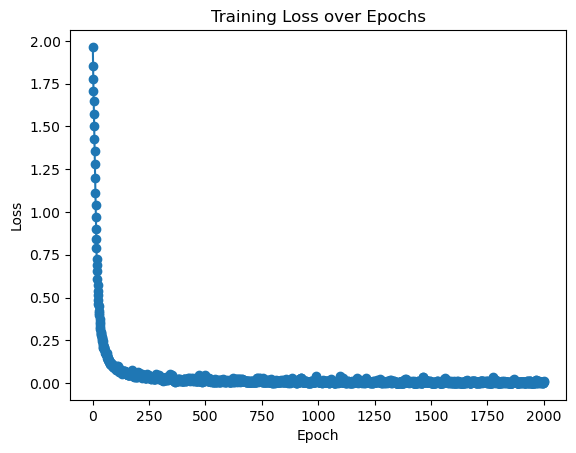

Final training loss: 0.0044401946200947565
{'home_goals_train_accuracy': 1.0, 'home_goals_train_precision': 1.0, 'home_goals_valid_accuracy': 0.2656641604010025, 'home_goals_valid_precision': 0.16155226939978898, 'home_goals_test_accuracy': 0.2781954887218045, 'home_goals_test_precision': 0.1738545772818487, 'home_goals_train_lte_0_accuracy': 1.0, 'home_goals_train_lte_0_accuracy_std': 0.0, 'home_goals_train_lte_0_precision': 1.0, 'home_goals_train_lte_0_precision_std': 0.0, 'home_goals_train_gt_0_accuracy': 1.0, 'home_goals_train_gt_0_accuracy_std': 0.0, 'home_goals_train_gt_0_precision': 1.0, 'home_goals_train_gt_0_precision_std': 0.0, 'home_goals_train_gt_1_accuracy': 1.0, 'home_goals_train_gt_1_accuracy_std': 0.0, 'home_goals_train_gt_1_precision': 1.0, 'home_goals_train_gt_1_precision_std': 0.0, 'home_goals_train_gt_2_accuracy': 1.0, 'home_goals_train_gt_2_accuracy_std': 0.0, 'home_goals_train_gt_2_precision': 1.0, 'home_goals_train_gt_2_precision_std': 0.0, 'home_goals_train_gt_3

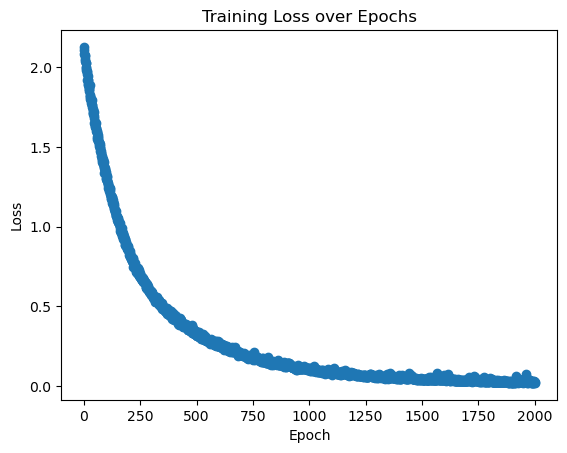

Final training loss: 0.01910525642073991
Training fold 2/5 with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


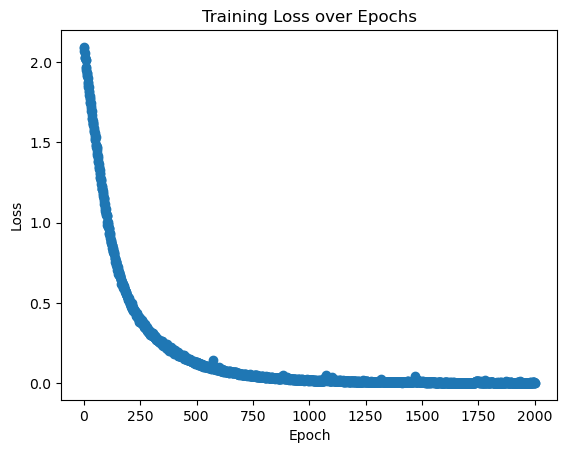

Final training loss: 0.002428265863838127
Training fold 3/5 with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


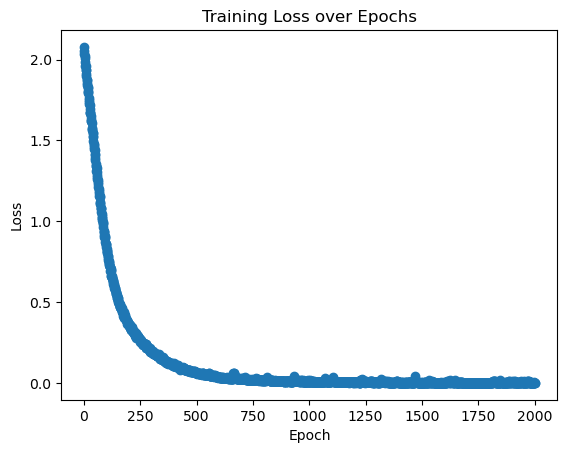

Final training loss: 0.0012473710968967141
Training fold 4/5 with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


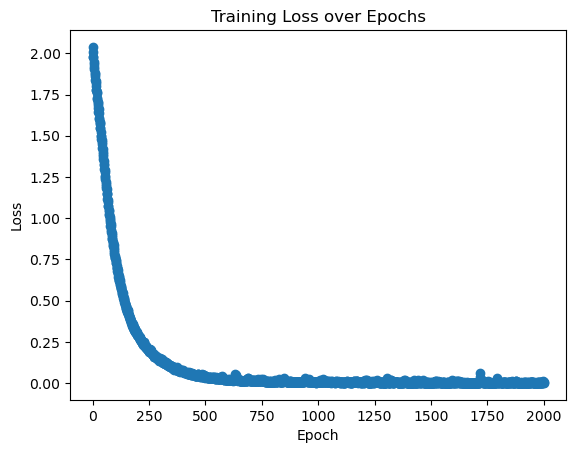

Final training loss: 0.004503409329213594
Training fold 5/5 with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


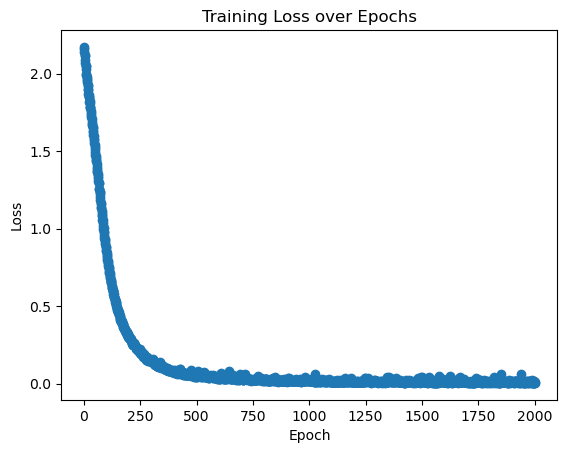

Final training loss: 0.0054052862588474925
[TorchWrapper] Using device: mps


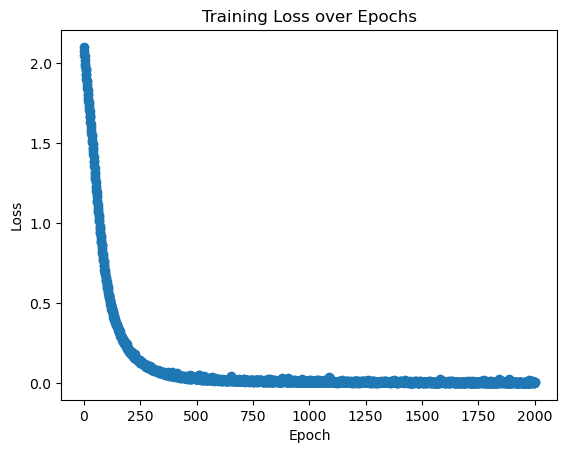

Final training loss: 0.004285735057148719
{'away_goals_train_accuracy': 1.0, 'away_goals_train_precision': 1.0, 'away_goals_valid_accuracy': 0.30025062656641605, 'away_goals_valid_precision': 0.14932579405644808, 'away_goals_test_accuracy': 0.2819548872180451, 'away_goals_test_precision': 0.14408956676398538, 'away_goals_train_lte_0_accuracy': 1.0, 'away_goals_train_lte_0_accuracy_std': 0.0, 'away_goals_train_lte_0_precision': 1.0, 'away_goals_train_lte_0_precision_std': 0.0, 'away_goals_train_gt_0_accuracy': 1.0, 'away_goals_train_gt_0_accuracy_std': 0.0, 'away_goals_train_gt_0_precision': 1.0, 'away_goals_train_gt_0_precision_std': 0.0, 'away_goals_train_gt_1_accuracy': 1.0, 'away_goals_train_gt_1_accuracy_std': 0.0, 'away_goals_train_gt_1_precision': 1.0, 'away_goals_train_gt_1_precision_std': 0.0, 'away_goals_train_gt_2_accuracy': 1.0, 'away_goals_train_gt_2_accuracy_std': 0.0, 'away_goals_train_gt_2_precision': 1.0, 'away_goals_train_gt_2_precision_std': 0.0, 'away_goals_train_gt_

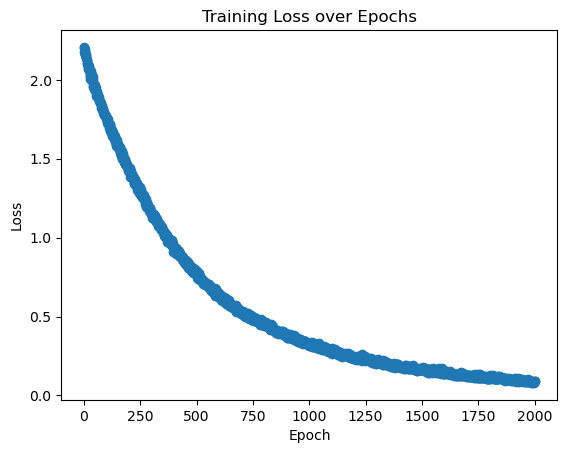

Final training loss: 0.09063986227625892
Training fold 2/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


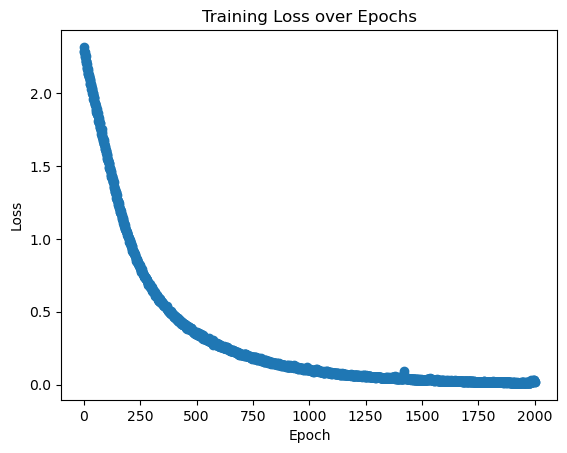

Final training loss: 0.017712615843498168
Training fold 3/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


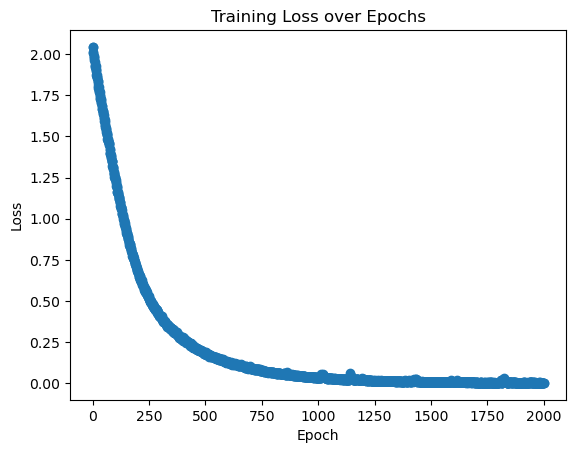

Final training loss: 0.0029807636014799726
Training fold 4/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


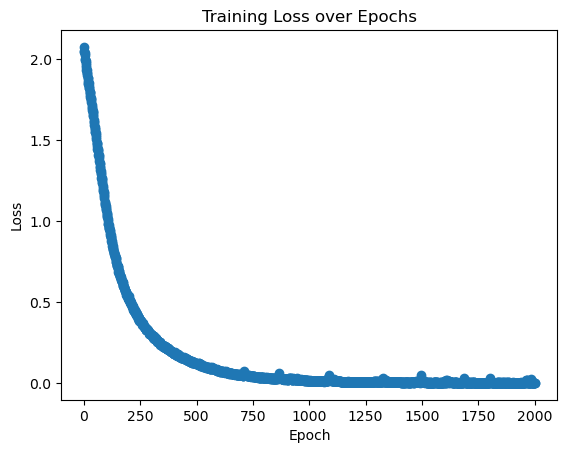

Final training loss: 0.002006068560213112
Training fold 5/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 2000}
[TorchWrapper] Using device: mps


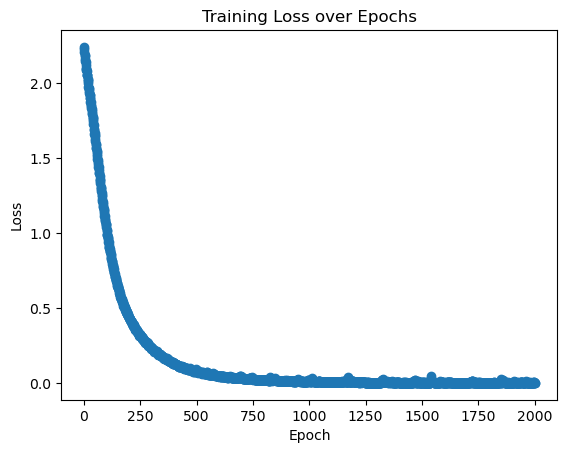

Final training loss: 0.002048582177816944
[TorchWrapper] Using device: mps


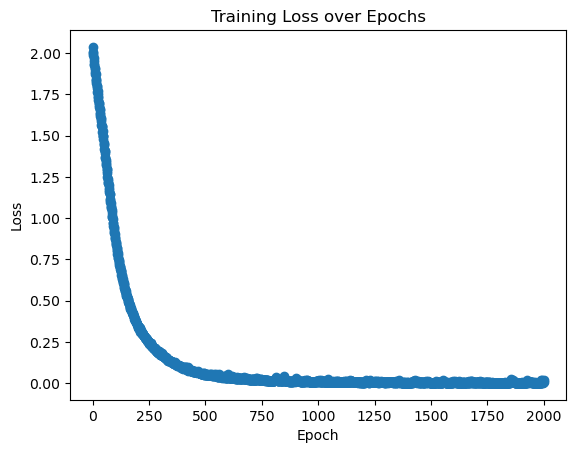

Final training loss: 0.005848850557734643
{'away_goals_train_accuracy': 1.0, 'away_goals_train_precision': 1.0, 'away_goals_valid_accuracy': 0.29473684210526313, 'away_goals_valid_precision': 0.14541606382617173, 'away_goals_test_accuracy': 0.2894736842105263, 'away_goals_test_precision': 0.14097382338219813, 'away_goals_train_lte_0_accuracy': 1.0, 'away_goals_train_lte_0_accuracy_std': 0.0, 'away_goals_train_lte_0_precision': 1.0, 'away_goals_train_lte_0_precision_std': 0.0, 'away_goals_train_gt_0_accuracy': 1.0, 'away_goals_train_gt_0_accuracy_std': 0.0, 'away_goals_train_gt_0_precision': 1.0, 'away_goals_train_gt_0_precision_std': 0.0, 'away_goals_train_gt_1_accuracy': 1.0, 'away_goals_train_gt_1_accuracy_std': 0.0, 'away_goals_train_gt_1_precision': 1.0, 'away_goals_train_gt_1_precision_std': 0.0, 'away_goals_train_gt_2_accuracy': 1.0, 'away_goals_train_gt_2_accuracy_std': 0.0, 'away_goals_train_gt_2_precision': 1.0, 'away_goals_train_gt_2_precision_std': 0.0, 'away_goals_train_gt_

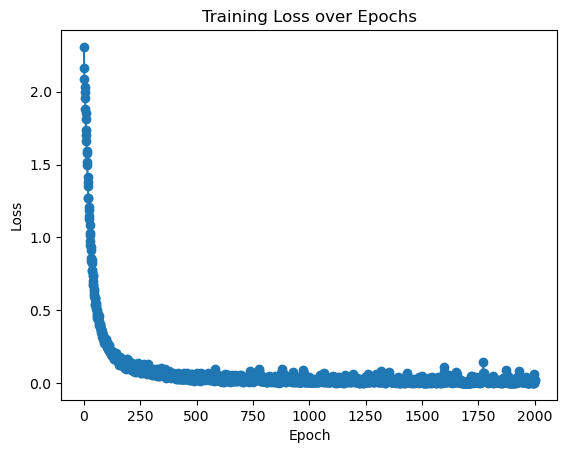

Final training loss: 0.02368034081496205
Training fold 2/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


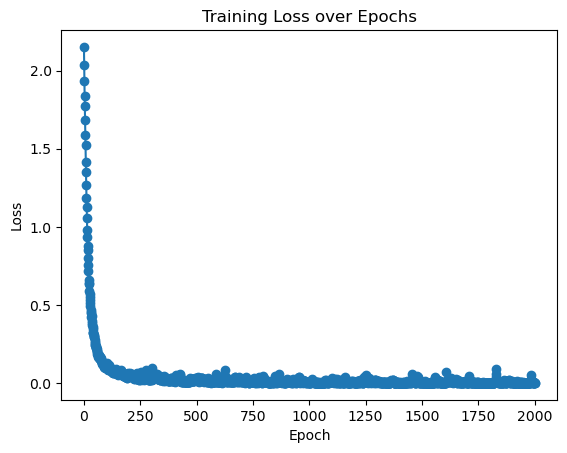

Final training loss: 0.002040108945337416
Training fold 3/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


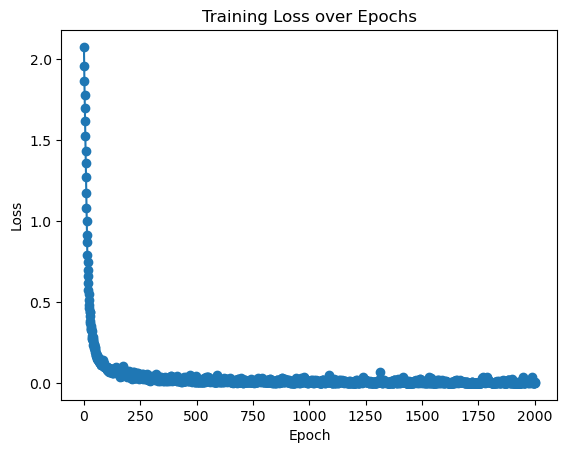

Final training loss: 0.0016098083023650225
Training fold 4/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


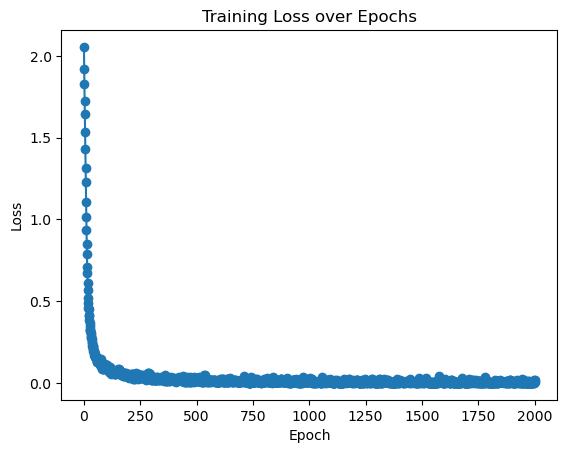

Final training loss: 0.0069006970537392265
Training fold 5/precision with params: {'model_params.hidden_layers': (512, 128, 128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 2000}
[TorchWrapper] Using device: mps


KeyboardInterrupt: 

In [9]:

run_multiclass_distribution_experiment(
    feature_df=feature_df,
    target_df=target_df,
    target_ranges=TRAINGING_CONFIG['target_ranges'],
    model_wrapper_class=lambda **params: TorchWrapper(
        model_class=MLPWithDropoutBN,
        model_params={k.replace('model_params.', ''): v for k, v in params.items() if k.startswith('model_params.')},
        learning_rate=params.get('learning_rate', 0.001),
        batch_size=params.get('batch_size', 64),
        epochs=params.get('epochs', 20)
    ),
    model_param_grid=param_grid,
    test_size=TRAINGING_CONFIG['test_size'],
    k=5,
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    uri=f'{REPO_PATH}/mlflow',
    model_name='MLPwithDropoutBN',
    key_columns=TRAINGING_CONFIG['key_columns'],
)

/Users/tianqihuang/Documents/GitHub/betbot/src/model/experiment_utils.py:126: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


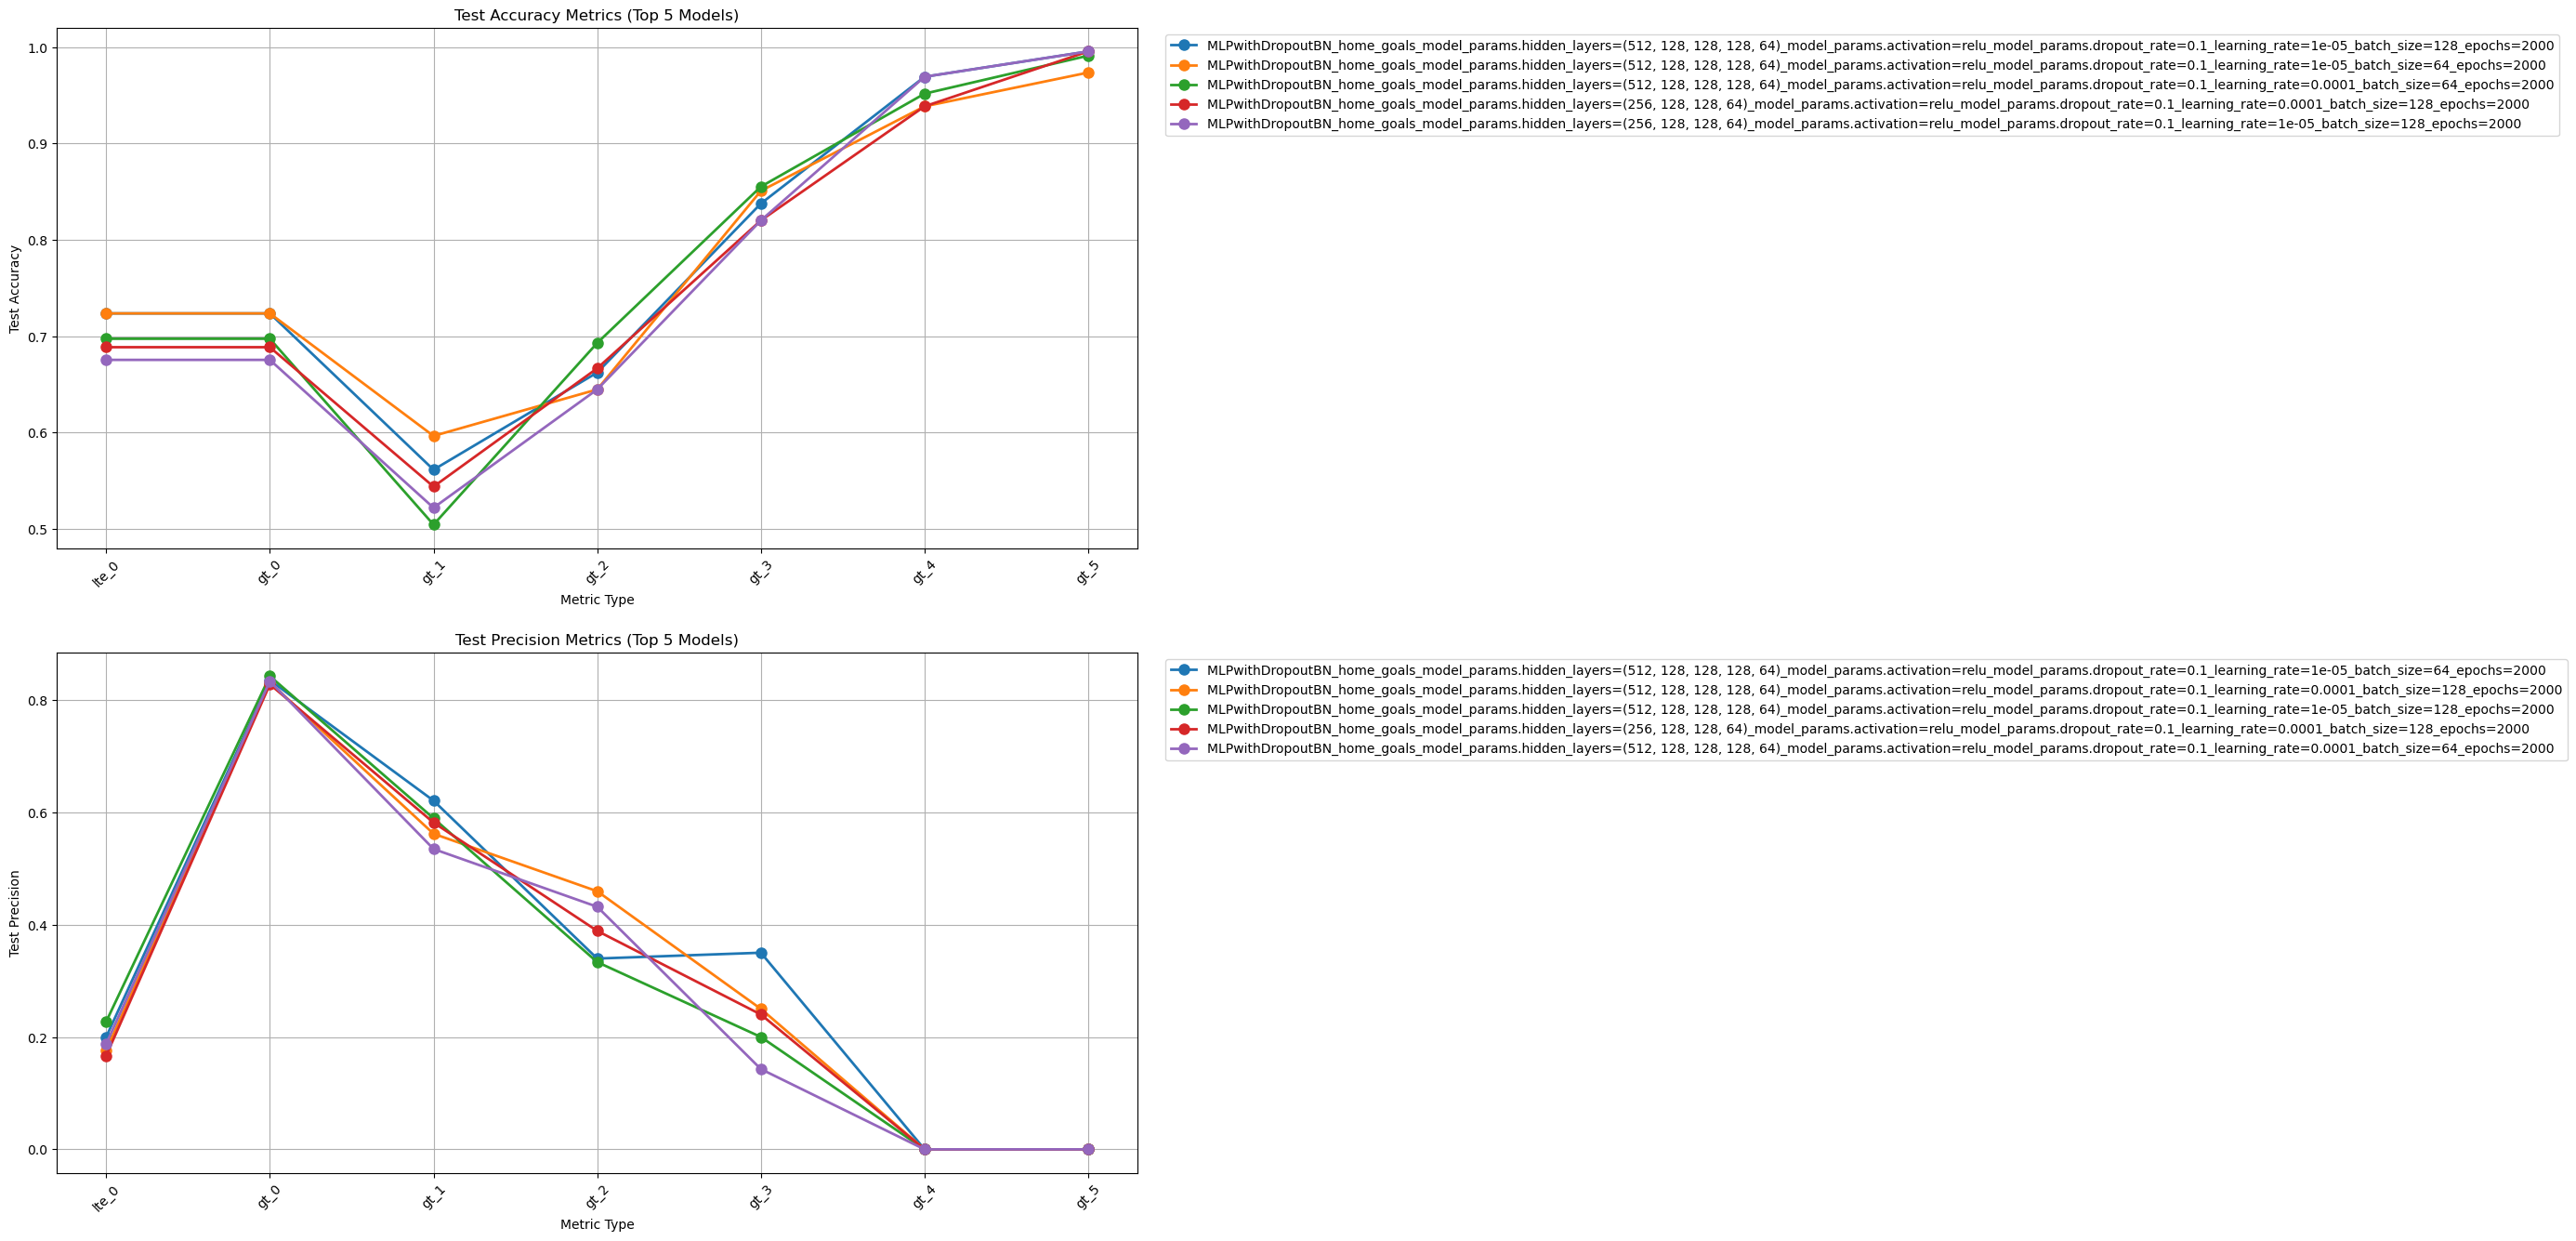

In [ ]:
plot_metrics_for_target_and_model(
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    target_col="home_goals",
    model_name="MLPwithDropoutBN",
    tracking_uri=f"{REPO_PATH}/mlflow"
)

In [ ]:
plot_run_metrics_by_split(experiment_name=TRAINGING_CONFIG['experiment_name'],
                         run_name="MLPwithDropoutBN_away_goals_{'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}",
                         target_col="home_goals",
                         tracking_uri=f"{REPO_PATH}/mlflow")

MlflowException: Invalid clause(s) in filter string: 'tags.mlflow.runName = 'MLPwithDropoutBN_away_goals_{'model_params.hidden_layers', '': (512, 256, 256, 128, 128), '', 'model_params.activation', '': '', 'relu', '', '', 'model_params.dropout_rate', '': 0, '', 'learning_rate', '': 1e-05, '', 'batch_size', '': 64, '', 'epochs', '': 5000}''

In [ ]:
plot_run_metrics_side_by_side(experiment_name=TRAINGING_CONFIG['experiment_name'],
                              model_name="MLPwithDropoutBN",
                              model_param={'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 0.00001, 'batch_size': 64, 'epochs': 5000},
                              tracking_uri=f"{REPO_PATH}/mlflow",
                              metric_type="precision")

Searching for runs with filter: params.model_name = 'MLPwithDropoutBN' and params.model_params.hidden_layers: '(512, 256, 256, 128, 128)' and params.model_params.activation: 'relu' and params.model_params.dropout_rate: '0' and params.learning_rate: '1e-05' and params.batch_size: '64' and params.epochs: '5000'


MlflowException: Invalid clause(s) in filter string: 'params.model_params.hidden_layers', ':', ''(512, 256, 256, 128, 128)'', 'params.model_params.activation', ':', ''relu'', 'params.model_params.dropout_rate', ':', ''0'', 'params.learning_rate', ':', ''1e-05'', 'params.batch_size', ':', ''64'', 'params.epochs', ':', ''5000''